In [1]:
import os
import sys
import pdfplumber
import polars as pl
from pydantic import BaseModel, field_validator
from IPython.display import display

# Add parent directory to Python path
notebook_dir = os.path.dirname(os.path.abspath(''))
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
	sys.path.append(parent_dir)

from src.utils.converter import format_luas, format_number, format_pulau

In [2]:
current_path = os.getcwd()
script_dir = os.path.dirname(current_path)
input_dir = os.path.join(script_dir, "datas")
print(current_path)
print(input_dir)

d:\Develop\repo\db-wilayah-indonesia\src\notebooks
d:\Develop\repo\db-wilayah-indonesia\src\datas


In [3]:
class ProvinceIndexData(BaseModel):
    no: int
    kode: str
    provinsi: str
    jumlah_kabupaten: int
    jumlah_kota: int
    jumlah_kecamatan: int
    jumlah_kelurahan: int
    jumlah_desa: int
    luas_wilayah_km2: float
    jumlah_penduduk: int
    jumlah_pulau: int

    @field_validator(
        "no",
        "jumlah_kabupaten",
        "jumlah_kota",
        "jumlah_kecamatan",
        "jumlah_kelurahan",
        "jumlah_desa",
        "jumlah_penduduk",
        mode="before",
    )
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("jumlah_pulau", mode="before")
    @classmethod
    def validate_pulau_field(cls, v):
        if v is None or v == "":
            return 0
        return int(format_pulau(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode", "provinsi", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        return str(v) if v else ""

In [4]:
file_name = "Keputusan_Menteri_Dalam_Negeri_Nomor_300.2.2-2138_Tahun_2025.pdf"
pdf_path = os.path.join(input_dir, file_name)

In [5]:
provinsi_index_settings = {
    "vertical_strategy": "lines",
    "horizontal_strategy": "text",
    "snap_y_tolerance": 7,
    "intersection_x_tolerance": 15,
}

In [6]:
start_page_index = 16
end_page_index = 17

page_numbers = list(range(start_page_index, end_page_index + 1))
print(page_numbers)

[16, 17]



Processing page 1:


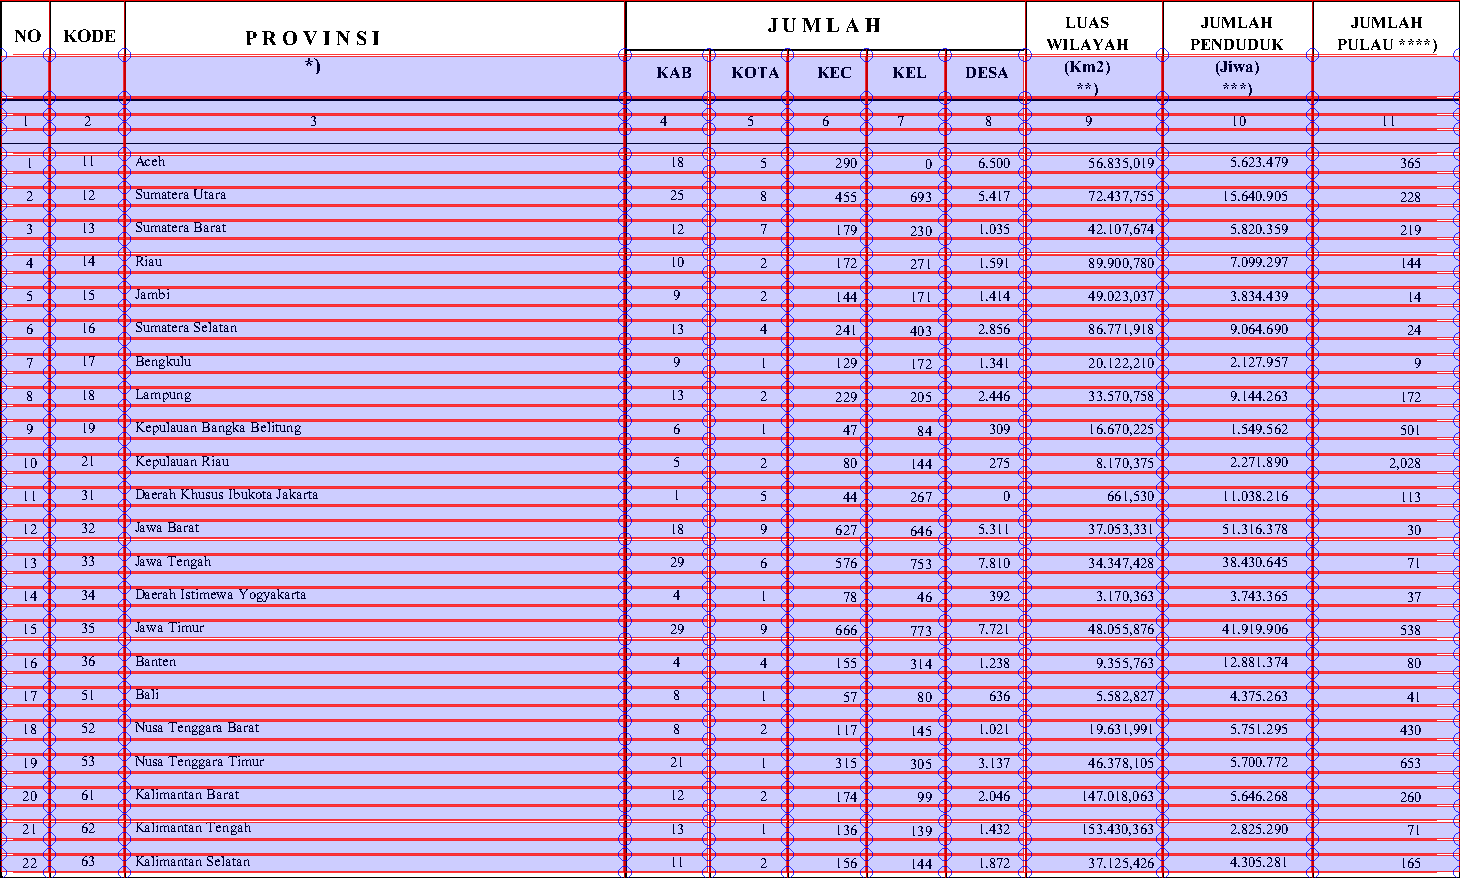


Processing page 2:


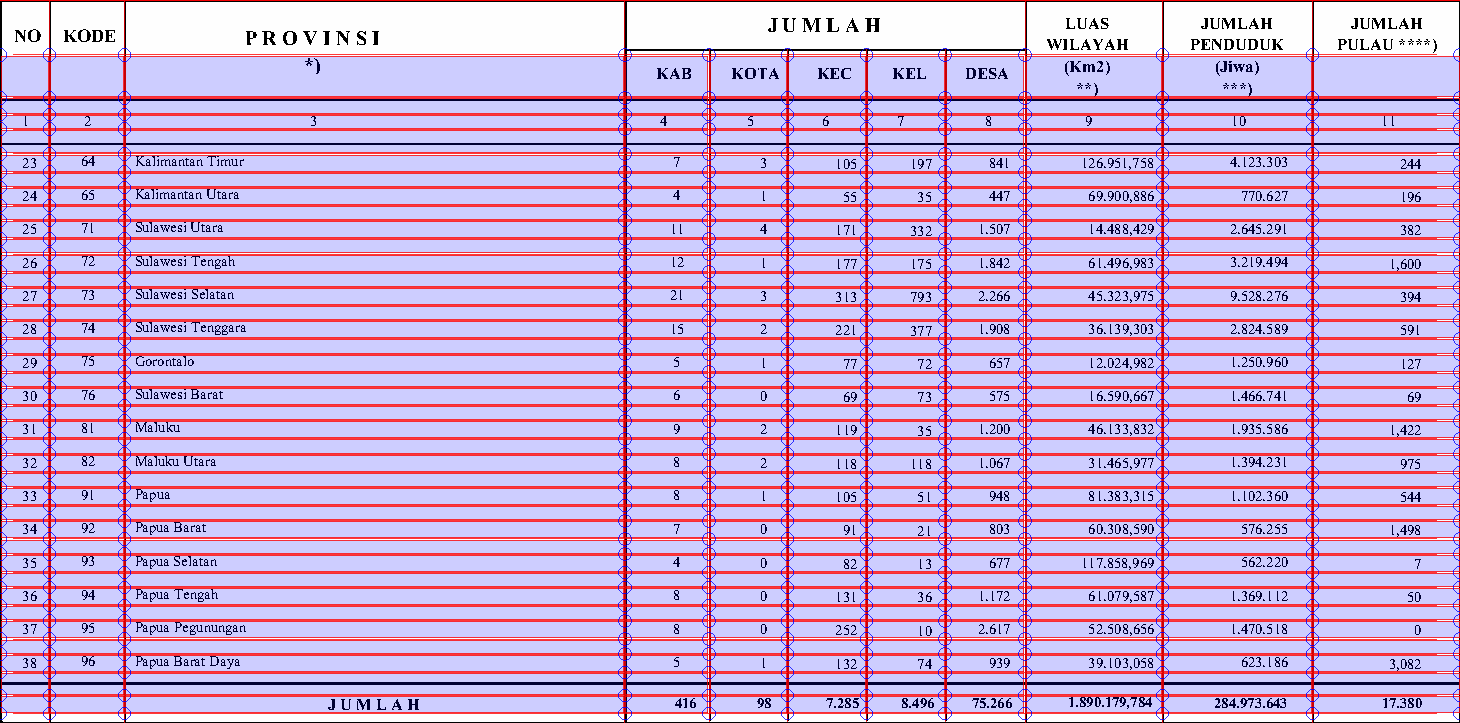

In [7]:
with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            print(f"\nProcessing page {i + 1}:")
            table = page.find_table()
            if table is not None and table.bbox is not None:
                table_bbox = table.bbox
                the_table = page.crop(table_bbox)
                im = the_table.to_image(resolution=150)
                table_extract = im.debug_tablefinder(provinsi_index_settings)
                value_table = the_table.extract_table(provinsi_index_settings)
                display(table_extract)
                replacement_value = ""

In [8]:
raw_records = []

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            table = page.extract_table(provinsi_index_settings)
            if table is not None:
                for row in table:
                    if any(row) :
                        raw_records.append(row)

In [9]:
def are_sublist_lengths_same(main_list):
    if not main_list:
        return True

    lengths = {len(sublist) for sublist in main_list}
    if len(lengths) == 1:
        return "Ok"
    else:
        raise ValueError("Not same length")


In [10]:
print(are_sublist_lengths_same(raw_records))

Ok


In [11]:
raw_records

[['',
  '',
  '*)',
  'KAB',
  'KOTA',
  'KEC',
  'KEL',
  'DESA',
  '(Km2)\n**)',
  '(Jiwa)\n***)',
  ''],
 ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11'],
 ['1',
  '11',
  'Aceh',
  '18',
  '5',
  '290',
  '0',
  '6.500',
  '56.835,019',
  '5.623.479',
  '365'],
 ['2',
  '12',
  'Sumatera Utara',
  '25',
  '8',
  '455',
  '693',
  '5.417',
  '72.437,755',
  '15.640.905',
  '228'],
 ['3',
  '13',
  'Sumatera Barat',
  '12',
  '7',
  '179',
  '230',
  '1.035',
  '42.107,674',
  '5.820.359',
  '219'],
 ['4',
  '14',
  'Riau',
  '10',
  '2',
  '172',
  '271',
  '1.591',
  '89.900,780',
  '7.099.297',
  '144'],
 ['5',
  '15',
  'Jambi',
  '9',
  '2',
  '144',
  '171',
  '1.414',
  '49.023,037',
  '3.834.439',
  '14'],
 ['6',
  '16',
  'Sumatera Selatan',
  '13',
  '4',
  '241',
  '403',
  '2.856',
  '86.771,918',
  '9.064.690',
  '24'],
 ['7',
  '17',
  'Bengkulu',
  '9',
  '1',
  '129',
  '172',
  '1.341',
  '20.122,210',
  '2.127.957',
  '9'],
 ['8',
  '18',
  'Lampung',
  '1

In [12]:
class ProvinceIndexData(BaseModel):
    no: int
    kode: str
    provinsi: str
    jumlah_kabupaten: int
    jumlah_kota: int
    jumlah_kecamatan: int
    jumlah_kelurahan: int
    jumlah_desa: int
    luas_wilayah_km2: float
    jumlah_penduduk: int
    jumlah_pulau: int

    @field_validator(
        "no",
        "jumlah_kabupaten",
        "jumlah_kota",
        "jumlah_kecamatan",
        "jumlah_kelurahan",
        "jumlah_desa",
        "jumlah_penduduk",
        mode="before",
    )
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("jumlah_pulau", mode="before")
    @classmethod
    def validate_pulau_field(cls, v):
        if v is None or v == "":
            return 0
        return int(format_pulau(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode", "provinsi", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        return str(v) if v else ""

In [13]:
clean_records = []

for row in raw_records:
    if len(row) >= 11:  # Ensure row has enough columns
        # Skip header/summary rows
        first_cell = str(row[0]).strip() if row[0] else ""
        third_cell = str(row[2]).strip() if len(row) > 2 and row[2] else ""

        # Skip if first column is not numeric, or third column (province) is numeric
        if not (first_cell and first_cell.isdigit()) or third_cell.isdigit():
             continue  # Skip header/summary rows

        data = ProvinceIndexData(
            no=row[0],
            kode=row[1],
            provinsi=row[2],
            jumlah_kabupaten=row[3],
            jumlah_kota=row[4],
            jumlah_kecamatan=row[5],
            jumlah_kelurahan=row[6],
            jumlah_desa=row[7],
            luas_wilayah_km2=row[8],
            jumlah_penduduk=row[9],
            jumlah_pulau=row[10],
        )
        clean_records.append(data)

In [14]:
pl.DataFrame([data.model_dump() for data in clean_records])

no,kode,provinsi,jumlah_kabupaten,jumlah_kota,jumlah_kecamatan,jumlah_kelurahan,jumlah_desa,luas_wilayah_km2,jumlah_penduduk,jumlah_pulau
i64,str,str,i64,i64,i64,i64,i64,f64,i64,i64
1,"""11""","""Aceh""",18,5,290,0,6500,56835.019,5623479,365
2,"""12""","""Sumatera Utara""",25,8,455,693,5417,72437.755,15640905,228
3,"""13""","""Sumatera Barat""",12,7,179,230,1035,42107.674,5820359,219
4,"""14""","""Riau""",10,2,172,271,1591,89900.78,7099297,144
5,"""15""","""Jambi""",9,2,144,171,1414,49023.037,3834439,14
…,…,…,…,…,…,…,…,…,…,…
34,"""92""","""Papua Barat""",7,0,91,21,803,60308.59,576255,1498
35,"""93""","""Papua Selatan""",4,0,82,13,677,117858.969,562220,7
36,"""94""","""Papua Tengah""",8,0,131,36,1172,61079.587,1369112,50
